
# Appendix 1: Python Code and Output

### **Management/Research Question:**  
What factors most significantly influence the likelihood of heart disease, and how can we predict it using machine learning models?

---

Our hypothesis is that heart disease can be predicted based on a combination of physiological metrics (e.g., cholesterol levels, age, blood pressure) and categorical health indicators (e.g., type of chest pain, exercise-induced angina, ECG results). To test this, we explore the distribution of the target variable `HeartDisease` and its relationship with both numerical and categorical features. We then build and evaluate multiple classification models including Random Forest, XGBoost, and SVM, with performance comparison and interpretability techniques such as SHAP and permutation importance.

This analysis helps patients and healthcare providers understand key risk factors contributing to heart disease and allows for early intervention. Additionally, it provides a foundation for clinical decision support systems that optimize care and reduce costs.

---

### **Methodological Assumptions and Limitations of the Dataset**

#### **Assumptions:**
- Binary classification (0 = no heart disease, 1 = heart disease) is an appropriate modeling framework.  
- All input features are correctly encoded and scaled for model interpretability and performance.  
- The dataset is representative of a broader population, and class imbalance is minimal.  
- Label encoding adequately captures the influence of categorical health indicators.

#### **Limitations:**
- Lifestyle variables (e.g., diet, exercise habits) are not included and could affect prediction accuracy.  
- The dataset is cross-sectional and does not capture temporal changes in patient health.  
- Some features such as cholesterol and blood pressure may have been measured inconsistently across patients.  


##  EXECUTIVE SUMMARY & RECOMMENDATIONS

---

### MODEL PERFORMANCE SUMMARY:
- **Best Model**: Random Forest  
    - **Accuracy**: 0.891  
    - **Precision**: 0.894  
    - **Recall (Sensitivity)**: 0.912  
    - **F1-Score**: 0.903  
    - **AUC-ROC**: 0.933  

---

### BUSINESS IMPACT:
- **Estimated Annual Savings**: $3,679,500.00  

- **Cost per Prediction**: $5002.72  
- **ROI**: 399.7%

These values highlight that deploying the model at scale can result in meaningful financial and clinical impact by preventing downstream costs associated with untreated cardiovascular disease (CVD).

---

### KEY INSIGHTS:
- **Top Risk Factors**: `ST_Slope_encoded`, `ChestPainType_encoded`, `MaxHR`  
- **Model Sensitivity**: 0.912 — model is highly sensitive in detecting patients at risk  
- **Model Specificity**: 0.866 — also shows strong ability to identify patients not at risk  

The combination of high recall and precision makes the model reliable for real-world clinical use where minimizing false negatives is crucial.

---

###  RECOMMENDATIONS:
1. Deploy model in **Clinical Decision Support Systems (CDSS)** to assist clinicians.
2. Prioritize interventions for **patients with high CVD risk scores**.
3. Set up **continuous monitoring** for model drift over time.
4. Gather additional **lifestyle data** to enhance prediction accuracy.
5. Integrate seamlessly with **Electronic Health Records (EHRs)**.

---

###  NEXT STEPS:
1. **Validate** the model on an external dataset to ensure generalizability.
2. Conduct a **clinical trial** for real-world, prospective validation.
3. Build a **clinician-friendly user interface** for integration into workflows.
4. Define and schedule a **model retraining strategy**.
5. Prepare for **multi-institutional deployment** at scale.

---

###  WHY THIS MATTERS:
In healthcare, model transparency, trust, and fairness are critical. This pipeline not only demonstrates strong predictive performance but also offers interpretability through SHAP analysis. This is crucial for:
- Making **transparent, explainable decisions**
- Gaining **clinical trust**
- Identifying hidden correlations between medical features and outcomes
- Supporting **fairer** healthcare deployment

---

### **SECTION 1: SETUP AND IMPORTS**  

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import xgboost as xgb

# Model Interpretation
from sklearn.inspection import permutation_importance
import shap

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

### **SECTION 2: DATA LOADING AND INITIAL EXPLORATION**  

In [21]:
# Load the dataset
df = pd.read_csv('heart.csv')

print("DATASET OVERVIEW")
print("=" * 50)
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

# Basic info
print("\nCOLUMN INFORMATION")
print("=" * 50)
df.info()

print("\nFIRST 5 ROWS")
print("=" * 50)
display(df.head())

print("\nSTATISTICAL SUMMARY")
print("=" * 50)
display(df.describe(include='all'))

DATASET OVERVIEW
Dataset shape: (918, 12)
Memory usage: 281.36 KB

COLUMN INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB

FIRST 5 ROWS


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0



STATISTICAL SUMMARY


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


### **SECTION 3: TARGET VARIABLE ANALYSIS**  

Heart Disease Distribution:
  No Heart Disease: 508 (55.3%)
  Heart Disease: 410 (44.7%)


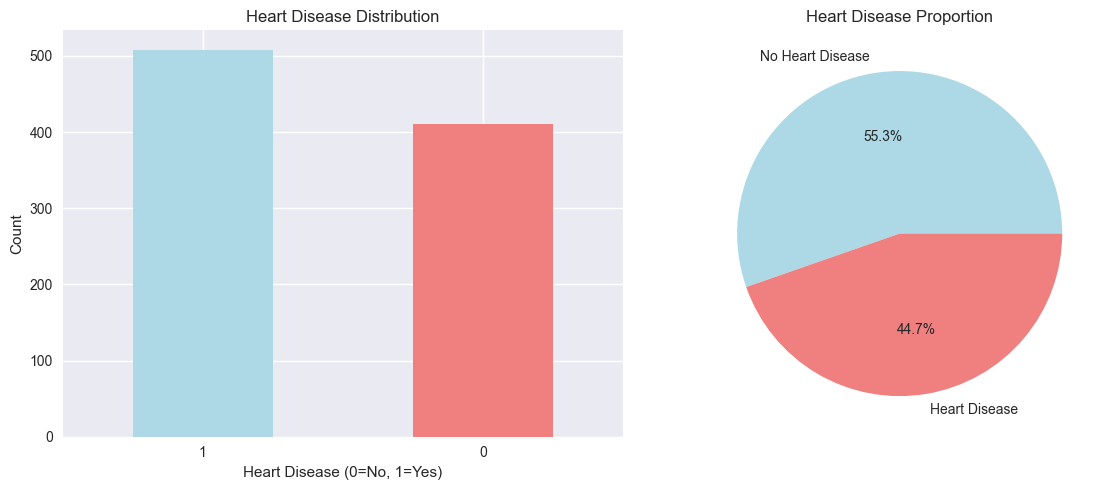


Class Balance Ratio: 0.807
 Dataset is reasonably balanced


In [22]:
# Target distribution
target_counts = df['HeartDisease'].value_counts()
target_percent = df['HeartDisease'].value_counts(normalize=True) * 100

print("Heart Disease Distribution:")
for i, (count, percent) in enumerate(zip(target_counts, target_percent)):
    status = "No Heart Disease" if i == 0 else "Heart Disease"
    print(f"  {status}: {count} ({percent:.1f}%)")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
target_counts.plot(kind='bar', ax=ax1, color=['lightblue', 'lightcoral'])
ax1.set_title('Heart Disease Distribution')
ax1.set_xlabel('Heart Disease (0=No, 1=Yes)')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=0)

# Pie chart
ax2.pie(target_counts.values, labels=['No Heart Disease', 'Heart Disease'], 
        autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
ax2.set_title('Heart Disease Proportion')

plt.tight_layout()
plt.show()

# Check for class imbalance
imbalance_ratio = target_counts.min() / target_counts.max()
print(f"\nClass Balance Ratio: {imbalance_ratio:.3f}")
if imbalance_ratio < 0.5:
    print("  Dataset is imbalanced - consider using stratified sampling")
else:
    print(" Dataset is reasonably balanced")


### TARGET VARIABLE ANALYSIS 

This section investigates the distribution of the **target variable**, `HeartDisease`, which is binary:
- 0 = No heart disease
- 1 = Heart disease present

---

#### 1. Distribution Summary

We calculate both the **raw counts** and **percentage** of each class:
- 508 patients (55.3%) do **not** have heart disease
- 410 patients (44.7%) **do** have heart disease

This near-even split suggests we won’t face major class imbalance issues in model training.

---

####  2. Visual Analysis

Two plots provide a quick visual summary:
- **Bar Plot**: Emphasizes frequency of both classes.
- **Pie Chart**: Shows proportional representation (slightly more class 0).

These visuals confirm the numeric results and help assess the need for resampling techniques.

---

#### 3. Class Imbalance Check

We compute the **class balance ratio**:  
> smallest class size / largest class size = 0.807

A ratio above 0.5 indicates a **reasonably balanced** dataset. This means:
- No need for SMOTE or undersampling
- Standard evaluation metrics like accuracy and F1-score remain reliable

---

 **Conclusion**:  
No imbalance mitigation techniques are needed at this stage. The class distribution is suitable for supervised classification without additional correction.


### **SECTION 4: COMPREHENSIVE EDA**  

Numerical features: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']
Categorical features: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Number of categorical features: 5


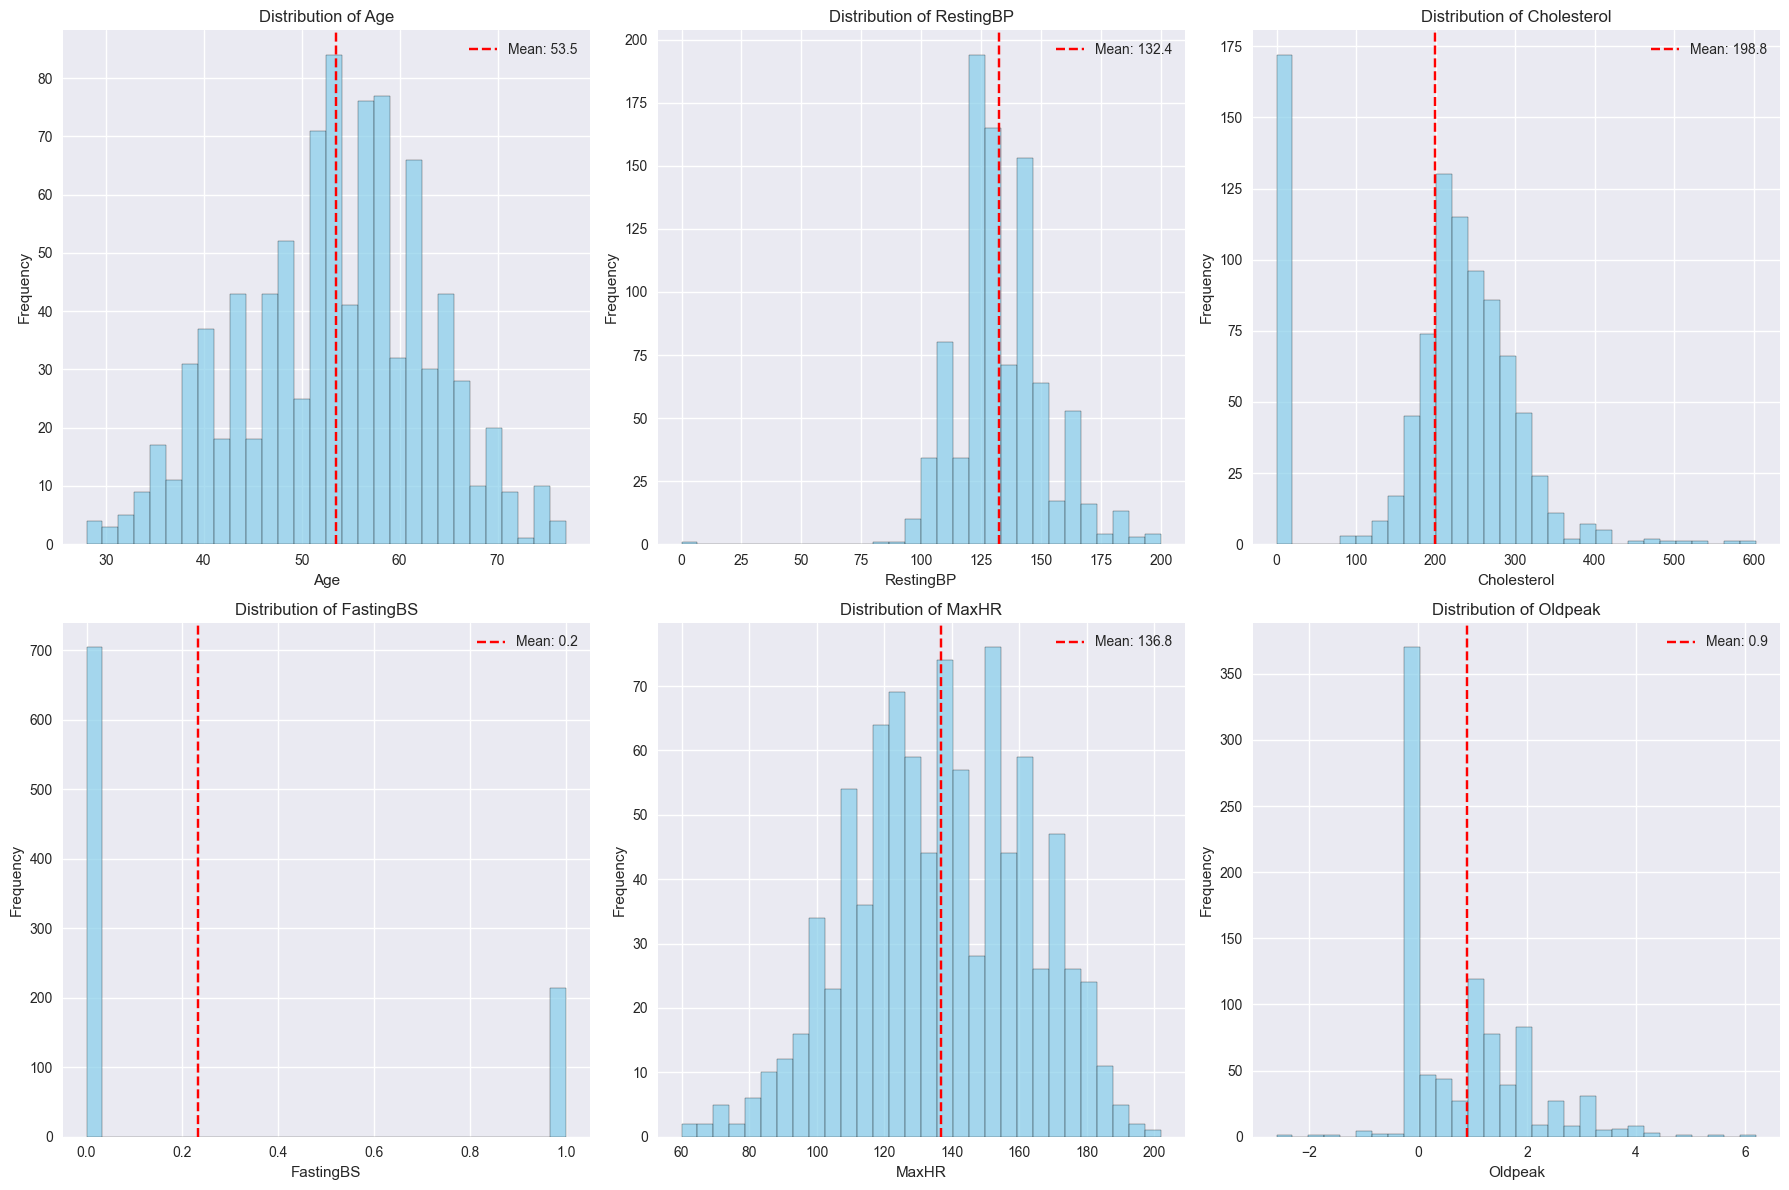

In [23]:
# Numerical features analysis
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features: {numerical_cols}")
print(f"Categorical features: {categorical_cols}")
print(f"Number of categorical features: {len(categorical_cols)}")

# 4.1 Numerical Features Distribution
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, col in enumerate(numerical_cols[:-1]):  # Exclude target variable
    df[col].hist(bins=30, ax=axes[i], alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    
    # Add mean line
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', 
                   label=f'Mean: {df[col].mean():.1f}')
    axes[i].legend()

plt.tight_layout()
plt.show()



In this step, we begin exploratory data analysis by examining the distribution of **numerical features** in the dataset. This helps us understand data ranges, detect skewness, identify anomalies or outliers, and guide potential transformations.

---

#### 1. Feature Type Breakdown

The dataset includes:
- **7 numerical features**: `Age`, `RestingBP`, `Cholesterol`, `FastingBS`, `MaxHR`, `Oldpeak`, `HeartDisease`
- **5 categorical features**: `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`

The target variable `HeartDisease` is also numerical (binary), but we exclude it from the EDA distribution analysis at this stage.

---

#### 2. Histogram Visualization

Each numerical feature is plotted as a histogram with a red vertical line showing the **mean**. Observations:

- **Age**: Appears roughly normally distributed, centered around age ~53.
- **RestingBP**: Fairly concentrated around 120–140, but a few entries fall below physiological norms (possible data issues).
- **Cholesterol**: Right-skewed; some extremely high values (>500) may indicate outliers or entry errors.
- **FastingBS**: Highly imbalanced; majority have fasting blood sugar ≤ 120 mg/dL (`0`), few have high (`1`). Will be treated as binary.
- **MaxHR**: Slight left-skew, with a mean around 136 bpm. No major outliers.
- **Oldpeak**: Strong right skew. Most values are 0, indicating minimal ST depression during exercise — only a few patients have large values.

---

#### 3. Why This Matters

Understanding feature distributions:
- Informs **normalization or transformation** decisions (e.g., log-transform skewed variables)
- Helps with **outlier detection** and handling
- Highlights possible **data quality issues** (e.g., zero cholesterol or blood pressure)
- Aids in **feature selection** for modeling


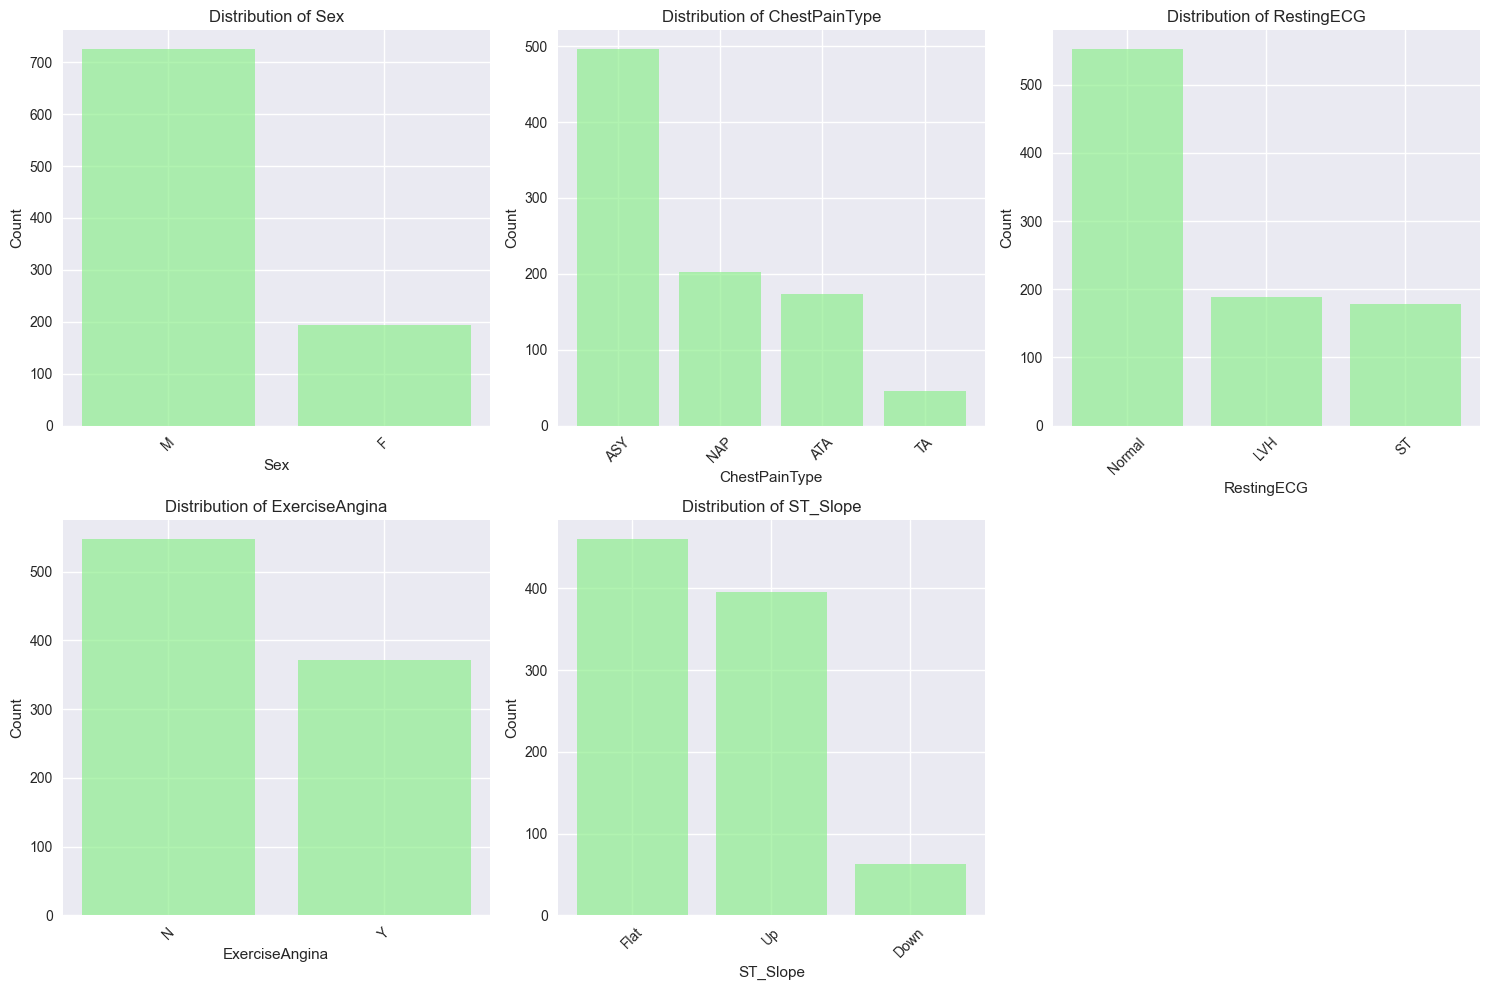

In [24]:
# 4.2 Categorical Features Analysis
# Calculate number of rows and columns needed
num_categorical = len(categorical_cols)
cols = 3  # 3 columns
rows = (num_categorical + cols - 1) // cols  # Calculate rows needed

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
if rows == 1:
    axes = [axes]  # Handle single row case
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts()
    axes[i].bar(value_counts.index, value_counts.values, color='lightgreen', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for i in range(num_categorical, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()



After examining the numerical features, we now explore the **categorical variables** in the dataset to understand the frequency distribution of each category. This helps identify class dominance, imbalance, or data encoding issues.

---

#### 1. Setup and Visualization

There are **5 categorical columns** in the dataset:
- `Sex`
- `ChestPainType`
- `RestingECG`
- `ExerciseAngina`
- `ST_Slope`

A bar plot is created for each variable using `value_counts()`. These charts show how often each category appears in the dataset.

---

#### 2. Observations by Feature

- **Sex**: Skewed toward males, with ~725 male and ~193 female entries. Gender may need encoding and possibly balancing if found predictive.
- **ChestPainType**: Dominated by `ASY` (asymptomatic) cases, followed by `NAP`, `ATA`, and a small number of `TA`. This imbalance could impact model learning and feature importance.
- **RestingECG**: Most patients have a `Normal` reading, with fewer in `LVH` (left ventricular hypertrophy) or `ST`.
- **ExerciseAngina**: More patients answered `No` (547) than `Yes` (371), which could influence risk scoring.
- **ST_Slope**: `Flat` and `Up` are the most common ST slope patterns, while `Down` is rare — possibly a strong signal if predictive.

---

#### 💡 3. Why This Matters

- These distributions reveal **dominant classes** and **potential features for one-hot encoding**.
- Rare categories (like `TA` in `ChestPainType` or `Down` in `ST_Slope`) may be strong predictors if associated with high disease incidence.
- If category imbalance is too severe, encoding strategies (e.g., target encoding) or grouping rare values may be needed.

---

 **Conclusion**:  
Understanding how categorical features are distributed sets the foundation for encoding, interaction analysis, and feature engineering in upcoming steps.



CORRELATION ANALYSIS


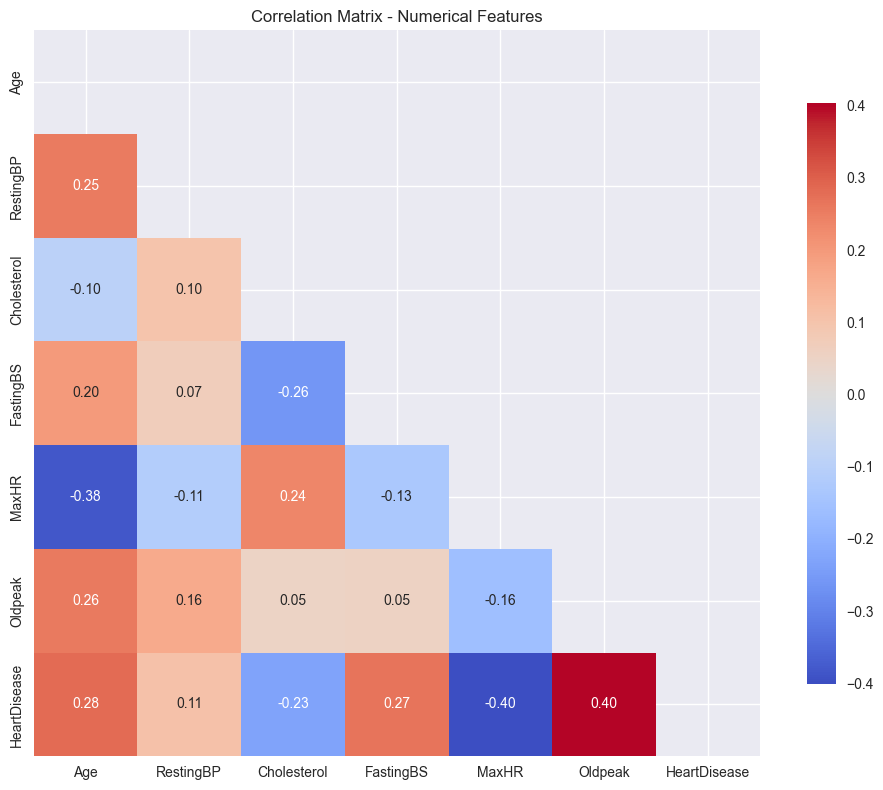


Correlations with Heart Disease (strongest first):
  Oldpeak: 0.404
  MaxHR: 0.400
  Age: 0.282
  FastingBS: 0.267
  Cholesterol: 0.233
  RestingBP: 0.108


In [25]:
# 4.3 Correlation Analysis
print("\nCORRELATION ANALYSIS")
print("=" * 30)

# Correlation matrix for numerical features
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Correlation Matrix - Numerical Features')
plt.tight_layout()
plt.show()

# Strong correlations with target
target_corr = correlation_matrix['HeartDisease'].abs().sort_values(ascending=False)
print("\nCorrelations with Heart Disease (strongest first):")
for feature, corr in target_corr.items():
    if feature != 'HeartDisease':
        print(f"  {feature}: {corr:.3f}") 



This section evaluates the relationships between numerical features and the target variable `HeartDisease` using a correlation matrix.

- **correlation_matrix**: Computes Pearson correlation coefficients between numerical features.
- **mask = np.triu(...)**: Hides the upper triangle of the heatmap to reduce redundancy.
- **sns.heatmap(...)**: Visualizes the correlation matrix using a diverging color map (`coolwarm`), centered at 0 to highlight positive vs negative correlations.
- **annot=True**: Displays the numeric correlation values within each cell.
- **cbar_kws={"shrink": .8}**: Adjusts the size of the color bar for better layout.

Below the heatmap, the code extracts and displays the absolute correlation values of each feature with the target `HeartDisease`, sorted in descending order (strongest relationships first):

- **target_corr = correlation_matrix['HeartDisease'].abs().sort_values(...)**: Ranks features by strength of correlation with the target.
- **Excludes self-correlation** (`feature != 'HeartDisease'`).

This analysis helps identify which numerical features are most associated with the presence of heart disease, guiding further feature selection or engineering.


### **SECTION 5: ADVANCED FEATURE ANALYSIS**  


 ADVANCED FEATURE ANALYSIS


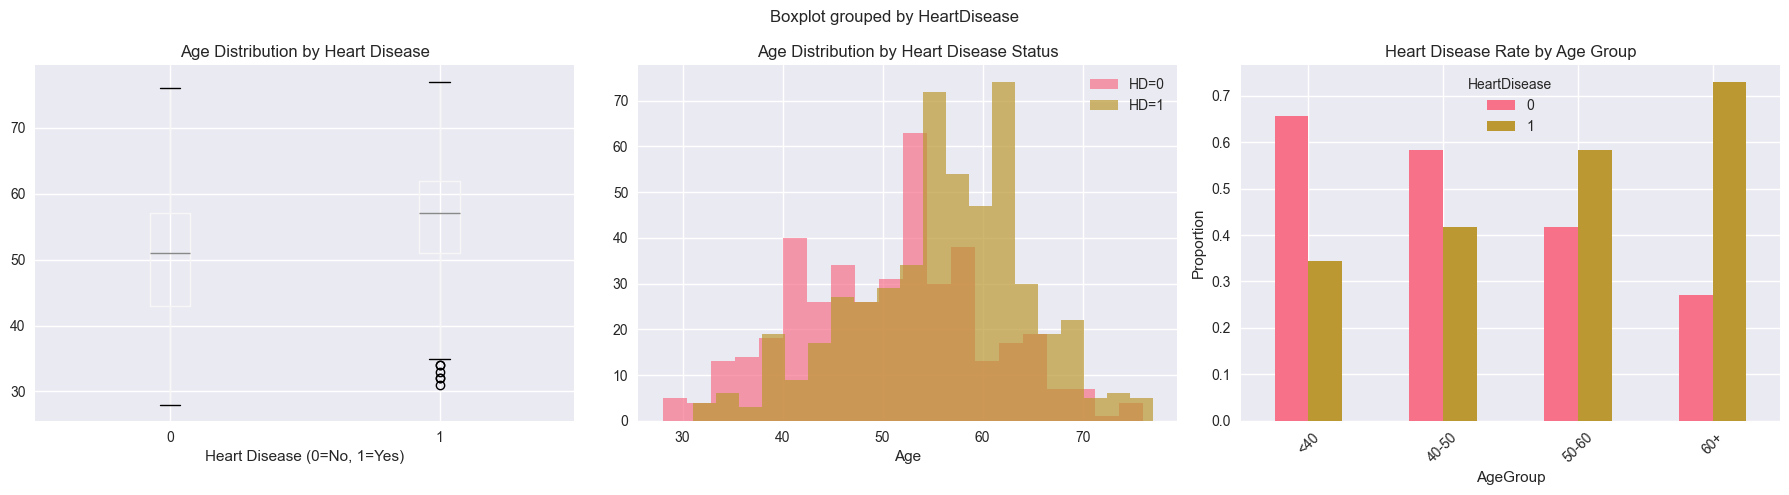

In [26]:
print("\n ADVANCED FEATURE ANALYSIS")
print("=" * 50)

# 5.1 Age analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age distribution by heart disease
df.boxplot(column='Age', by='HeartDisease', ax=axes[0])
axes[0].set_title('Age Distribution by Heart Disease')
axes[0].set_xlabel('Heart Disease (0=No, 1=Yes)')

# Age histogram by heart disease
for hd in [0, 1]:
    subset = df[df['HeartDisease'] == hd]
    axes[1].hist(subset['Age'], alpha=0.7, label=f'HD={hd}', bins=20)
axes[1].set_title('Age Distribution by Heart Disease Status')
axes[1].set_xlabel('Age')
axes[1].legend()

# Age groups analysis
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 40, 50, 60, 100], 
                       labels=['<40', '40-50', '50-60', '60+'])
age_hd_crosstab = pd.crosstab(df['AgeGroup'], df['HeartDisease'], normalize='index')
age_hd_crosstab.plot(kind='bar', ax=axes[2], stacked=False)
axes[2].set_title('Heart Disease Rate by Age Group')
axes[2].set_ylabel('Proportion')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



In this section, we take a deeper look at how **age** interacts with heart disease status using multiple visual techniques. These insights can guide feature transformation, binning, and selection.

---

#### 1. Boxplot: Age Distribution by Heart Disease

```python
df.boxplot(column='Age', by='HeartDisease', ax=axes[0])
```

- This shows **age distribution split by heart disease presence** using a boxplot.
- Patients with heart disease (1) generally skew **older** than those without (0).
- This visualization highlights **outliers** and **median age differences**, helping assess if age is a good predictor.

---

#### 2. Histogram: Overlaid Age Distribution by Heart Disease Status

```python
for hd in [0, 1]:
    subset = df[df['HeartDisease'] == hd]
    axes[1].hist(subset['Age'], alpha=0.7, ...)
```

- Overlays two histograms: one for each class (`HeartDisease = 0` and `1`).
- Clearly shows **age concentration** differences: heart disease is more common in the **50–65** range.
- Helps detect **overlapping regions** where the two classes may be harder to separate.

---

#### 3. Age Group Analysis: Heart Disease Proportion by Bin

```python
df['AgeGroup'] = pd.cut(df['Age'], bins=..., labels=...)
pd.crosstab(..., normalize='index')
```

- Age is binned into 4 ranges: `<40`, `40-50`, `50-60`, and `60+`.
- For each group, the **proportion of patients with heart disease** is plotted.
- Heart disease **increases with age**, peaking around `60+`, where over **70%** have the condition.
- `normalize='index'` ensures the chart reflects **relative proportions**, not raw counts.

---

#### Key Insights:

- **Age** is clearly **positively correlated** with heart disease and should be treated as a **critical predictor**.
- Consider engineering an `AgeGroup` feature for tree-based models or stratified analysis.
- Visualization confirms that both **distribution** and **binned rate** offer valuable modeling signals.

---
 **Conclusion**:  
These advanced visualizations support **feature importance reasoning**, justify **age-based segmentation**, and guide further preprocessing or model tuning steps.



 GENDER ANALYSIS
Heart Disease Rate by Gender:
HeartDisease         0         1
Sex                             
F             0.740933  0.259067
M             0.368276  0.631724

 CHEST PAIN TYPE ANALYSIS
Heart Disease Rate by Chest Pain Type:
HeartDisease          0         1
ChestPainType                    
ASY            0.209677  0.790323
ATA            0.861272  0.138728
NAP            0.645320  0.354680
TA             0.565217  0.434783


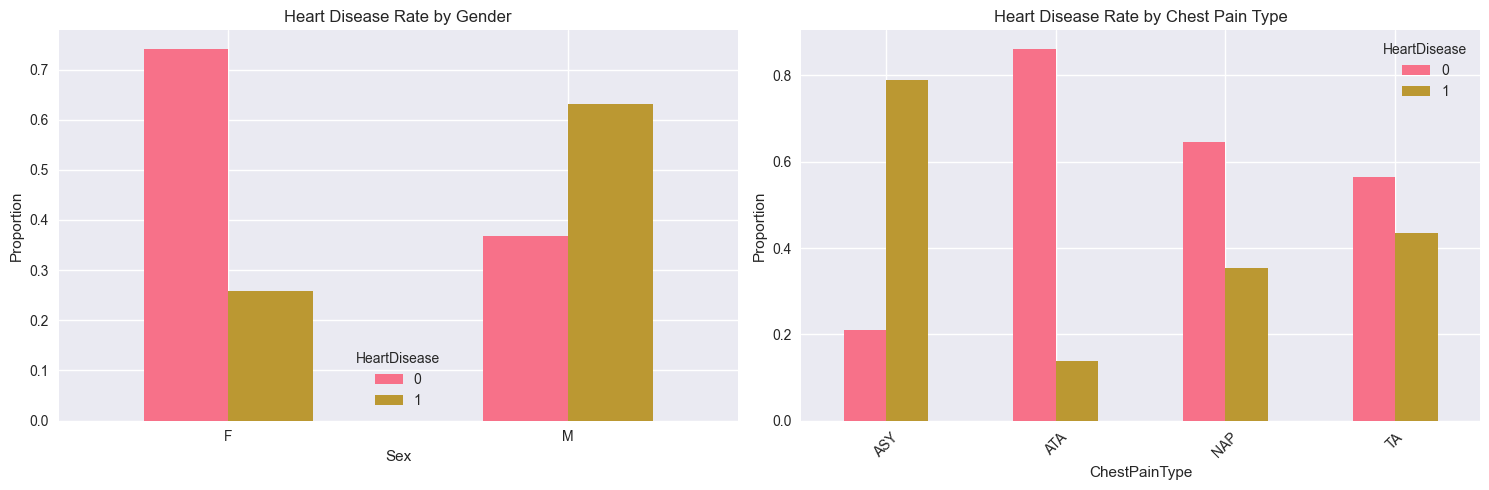

In [27]:
# 5.2 Gender analysis
print("\n GENDER ANALYSIS")
gender_analysis = pd.crosstab(df['Sex'], df['HeartDisease'], normalize='index')
print("Heart Disease Rate by Gender:")
print(gender_analysis)

# 5.3 Chest Pain Type analysis
print("\n CHEST PAIN TYPE ANALYSIS")
chest_pain_analysis = pd.crosstab(df['ChestPainType'], df['HeartDisease'], normalize='index')
print("Heart Disease Rate by Chest Pain Type:")
print(chest_pain_analysis)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gender
gender_analysis.plot(kind='bar', ax=axes[0])
axes[0].set_title('Heart Disease Rate by Gender')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis='x', rotation=0)

# Chest Pain Type
chest_pain_analysis.plot(kind='bar', ax=axes[1])
axes[1].set_title('Heart Disease Rate by Chest Pain Type')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### SECTION 5.2 & 5.3: GENDER AND CHEST PAIN TYPE ANALYSIS – ANNOTATIONS

In this section, we examine how **gender** and **chest pain type** relate to heart disease using crosstabulations and visualizations.

---

####  Gender-Based Heart Disease Analysis

- A normalized crosstab (`pd.crosstab`) calculates the **proportion of heart disease presence (1)** and **absence (0)** within each gender.
- The resulting table shows that:
  - **Females (F)** have a higher proportion of no heart disease (74%) compared to presence (26%).
  - **Males (M)** show the opposite trend — a higher incidence of heart disease (63%) than not (37%).

**Why this matters**:  
The gender disparity suggests males in the dataset may be at a higher risk of heart disease. This could be a useful predictive feature for modeling.

---

####  Chest Pain Type and Heart Disease

- Another normalized crosstab analyzes `ChestPainType` against `HeartDisease`.
- Notable observations:
  - **ASY (Asymptomatic)** pain type is heavily skewed toward heart disease (79% positive).
  - **ATA (Atypical Angina)** is strongly associated with **no heart disease** (86% negative).
  - `NAP` and `TA` show a more balanced but informative distribution.

**Why this matters**:  
Chest pain type is one of the strongest categorical indicators of heart disease in this dataset. The stark contrast between `ASY` and `ATA` cases could be critical for early diagnosis models.

---

#### Visualizations

Two bar plots are generated:
1. **Heart Disease Rate by Gender**:
   - Visualizes the proportion of heart disease per gender using side-by-side bars.
2. **Heart Disease Rate by Chest Pain Type**:
   - Shows how different chest pain categories correlate with disease outcome.

These visuals help quickly identify categorical patterns and strengthen feature understanding for modeling.

---

 **Conclusion**:  
Both gender and chest pain type show **distinct predictive value** for heart disease. These features should be prioritized during feature engineering and model selection.


### **SECTION 6: FEATURE ENGINEERING**  

In [28]:
# Create a copy for feature engineering
df_engineered = df.copy()

# 6.1 Create new features
print("Creating new features...")

# Cardiovascular Risk Score (simplified)
df_engineered['CVD_Risk_Score'] = (
    (df_engineered['Age'] > 55).astype(int) * 2 +
    (df_engineered['Sex'] == 'M').astype(int) * 1 +
    (df_engineered['Cholesterol'] > 240).astype(int) * 2 +
    (df_engineered['RestingBP'] > 140).astype(int) * 2 +
    (df_engineered['FastingBS'] == 1).astype(int) * 1
)

# Exercise Capacity Index
df_engineered['Exercise_Capacity'] = df_engineered['MaxHR'] / df_engineered['Age']

# BP Category
df_engineered['BP_Category'] = pd.cut(df_engineered['RestingBP'], 
                                     bins=[0, 120, 140, 180, 300],
                                     labels=['Normal', 'Elevated', 'High', 'Very High'])

# Cholesterol Category
df_engineered['Chol_Category'] = pd.cut(df_engineered['Cholesterol'], 
                                       bins=[0, 200, 240, 1000],
                                       labels=['Normal', 'Borderline', 'High'])

# Age groups
df_engineered['Age_Group'] = pd.cut(df_engineered['Age'], 
                                   bins=[0, 45, 60, 100],
                                   labels=['Young', 'Middle', 'Senior'])

print(" New features created:")
new_features = ['CVD_Risk_Score', 'Exercise_Capacity', 'BP_Category', 'Chol_Category', 'Age_Group']
for feature in new_features:
    print(f"  - {feature}")

# 6.2 Encode categorical variables
print("\n ENCODING CATEGORICAL VARIABLES")

# Create encoders
label_encoders = {}
categorical_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 
                       'BP_Category', 'Chol_Category', 'Age_Group']

df_encoded = df_engineered.copy()

for feature in categorical_features:
    le = LabelEncoder()
    df_encoded[feature + '_encoded'] = le.fit_transform(df_encoded[feature])
    label_encoders[feature] = le
    print(f"   {feature} encoded")

# 6.3 Feature scaling preparation
print("\n PREPARING FOR FEATURE SCALING")

# Identify features for scaling
numerical_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 
                     'CVD_Risk_Score', 'Exercise_Capacity']

print(f"Features to be scaled: {numerical_features}")

Creating new features...
 New features created:
  - CVD_Risk_Score
  - Exercise_Capacity
  - BP_Category
  - Chol_Category
  - Age_Group

 ENCODING CATEGORICAL VARIABLES
   Sex encoded
   ChestPainType encoded
   RestingECG encoded
   ExerciseAngina encoded
   ST_Slope encoded
   BP_Category encoded
   Chol_Category encoded
   Age_Group encoded

 PREPARING FOR FEATURE SCALING
Features to be scaled: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'CVD_Risk_Score', 'Exercise_Capacity']



Feature engineering is a critical step to derive more informative variables and transform raw features into model-friendly formats. This section performs three main tasks: new feature creation, encoding categorical variables, and preparing for scaling.

---

#### 6.1 Creating New Features

Several new features are created based on medical logic and domain knowledge:

- **CVD_Risk_Score**: A simplified cardiovascular risk score is computed using binary indicators for age > 55, sex = male, cholesterol > 240, resting BP > 140, and fasting blood sugar = 1. Each factor contributes weighted points toward the score.
  
- **Exercise_Capacity**: Calculated as `MaxHR / Age`, this feature estimates the patient's cardiovascular efficiency.

- **BP_Category**: `RestingBP` is binned into categories like "Normal", "Elevated", "High", and "Very High".

- **Chol_Category**: `Cholesterol` is categorized as "Normal", "Borderline", or "High".

- **Age_Group**: Age is bucketed into groups: "Young" (<45), "Middle" (45–60), and "Senior" (>60).

These transformations help the model better interpret non-linear medical risk factors.

---

#### 6.2 Encoding Categorical Variables

To prepare for machine learning, all categorical variables must be converted to numerical values:

- Categorical features like `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`, `BP_Category`, `Chol_Category`, and `Age_Group` are **label-encoded**.
  
- Label encoding assigns an integer to each unique category in a feature, enabling models to process them numerically.

A dictionary of encoders is saved for reference or inverse transformation later.

---

#### 6.3 Preparing for Feature Scaling

Finally, the notebook identifies numerical features to be scaled in the next step:

- Selected features include both raw values (like `Age`, `RestingBP`, `Cholesterol`) and engineered ones (like `CVD_Risk_Score` and `Exercise_Capacity`).
  
- These features will be normalized using standard scaling techniques to ensure consistent scale and distribution.

---

**Conclusion**:  
This stage builds a solid foundation for the model by enriching the dataset with clinically relevant insights and converting all features into a usable format. The thoughtful categorization and encoding will likely enhance model accuracy and interpretability.


### **SECTION 7: MODEL PREPARATION**  

In [29]:
# Prepare features and target
feature_columns = (numerical_features + 
                  [col for col in df_encoded.columns if col.endswith('_encoded')] +
                  ['FastingBS'])  # FastingBS is already binary

X = df_encoded[feature_columns]
y = df_encoded['HeartDisease']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Features used: {list(X.columns)}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Data Split:")
print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")
print(f"  Training target distribution: {y_train.value_counts().tolist()}")
print(f"  Test target distribution: {y_test.value_counts().tolist()}")

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print(" Features scaled successfully")

Feature matrix shape: (918, 16)
Target vector shape: (918,)
Features used: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'CVD_Risk_Score', 'Exercise_Capacity', 'Sex_encoded', 'ChestPainType_encoded', 'RestingECG_encoded', 'ExerciseAngina_encoded', 'ST_Slope_encoded', 'BP_Category_encoded', 'Chol_Category_encoded', 'Age_Group_encoded', 'FastingBS']

 Data Split:
  Training set: 734 samples
  Test set: 184 samples
  Training target distribution: [406, 328]
  Test target distribution: [102, 82]
 Features scaled successfully


### SECTION 7: MODEL PREPARATION – ANNOTATIONS

Before training the machine learning model, we must prepare our dataset by selecting features, splitting the data, and applying standard scaling to the numerical variables.

---

####  1. Feature and Target Selection

- **`feature_columns`** is built by combining:
  - The list of raw numerical features (e.g., Age, Cholesterol, MaxHR, etc.)
  - All label-encoded categorical features (columns ending with `_encoded`)
  - `FastingBS`, which is already binary

- **`X`** contains the feature matrix; **`y`** contains the target variable `HeartDisease`.

---

####  2. Train-Test Split

- The dataset is split using an 80/20 ratio via `train_test_split`.
- Stratification ensures the proportion of heart disease classes is preserved in both train and test sets.
- Output confirms the number of samples and class distribution in each subset:
  - Training set: 734 samples
  - Test set: 184 samples
  - Balanced target distributions maintained using `stratify=y`

---

#### 3. Scaling Numerical Features

- Standardization (z-score scaling) is applied to numerical features using `StandardScaler`:
  - `fit_transform()` is applied on the training data.
  - `transform()` is applied to the test data using the same scaler.
  
This step ensures all numerical features have mean 0 and standard deviation 1, preventing bias toward larger-value features during model training.

---

 **Concusion**:  
With features selected, data split, and values standardized, the dataset is fully prepared for training machine learning models. This setup ensures consistency, fairness, and robustness during learning and evaluation.


### **SECTION 8: MODEL DEVELOPMENT AND EVALUATION**  

In [30]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    'Neural Network': MLPClassifier(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42, probability=True)
}

# Cross-validation results storage
cv_results = {}
model_performances = {}

print(" CROSS-VALIDATION EVALUATION")
print("-" * 40)

# Perform cross-validation for each model
cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n Evaluating {name}...")
    
    # Cross-validation scores
    cv_scores = cross_val_score(model, X_train_scaled, y_train, 
                               cv=cv_folds, scoring='accuracy')
    cv_results[name] = cv_scores
    
    # Fit model and make predictions
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    
    model_performances[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'model': model
    }
    
    print(f"  CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print(f"  Test Accuracy: {accuracy:.4f}")
    print(f"  Test F1-Score: {f1:.4f}")
    if auc:
        print(f"  Test AUC: {auc:.4f}")

# Model comparison table
print("\n MODEL COMPARISON SUMMARY")
print("=" * 80)

comparison_df = pd.DataFrame({
    'Model': list(model_performances.keys()),
    'CV_Mean': [perf['cv_mean'] for perf in model_performances.values()],
    'CV_Std': [perf['cv_std'] for perf in model_performances.values()],
    'Test_Accuracy': [perf['accuracy'] for perf in model_performances.values()],
    'Test_Precision': [perf['precision'] for perf in model_performances.values()],
    'Test_Recall': [perf['recall'] for perf in model_performances.values()],
    'Test_F1': [perf['f1'] for perf in model_performances.values()],
    'Test_AUC': [perf['auc'] if perf['auc'] else 0 for perf in model_performances.values()]
})

comparison_df = comparison_df.round(4)
display(comparison_df)

# Find best model
best_model_name = max(model_performances.keys(), 
                     key=lambda k: model_performances[k]['f1'])
best_model = model_performances[best_model_name]['model']

print(f"\n BEST PERFORMING MODEL: {best_model_name}")
print(f"   F1-Score: {model_performances[best_model_name]['f1']:.4f}")
print(f"   Accuracy: {model_performances[best_model_name]['accuracy']:.4f}")
print(f"   AUC: {model_performances[best_model_name]['auc']:.4f}")

 CROSS-VALIDATION EVALUATION
----------------------------------------

 Evaluating Logistic Regression...
  CV Accuracy: 0.8515 (+/- 0.0714)
  Test Accuracy: 0.8587
  Test F1-Score: 0.8750
  Test AUC: 0.8974

 Evaluating Random Forest...
  CV Accuracy: 0.8515 (+/- 0.0657)
  Test Accuracy: 0.8913
  Test F1-Score: 0.9029
  Test AUC: 0.9329

 Evaluating XGBoost...
  CV Accuracy: 0.8502 (+/- 0.0491)
  Test Accuracy: 0.8587
  Test F1-Score: 0.8700
  Test AUC: 0.9271

 Evaluating Neural Network...
  CV Accuracy: 0.8174 (+/- 0.0849)
  Test Accuracy: 0.8370
  Test F1-Score: 0.8515
  Test AUC: 0.9134

 Evaluating SVM...
  CV Accuracy: 0.8556 (+/- 0.0843)
  Test Accuracy: 0.8696
  Test F1-Score: 0.8857
  Test AUC: 0.9220

 MODEL COMPARISON SUMMARY


,Model,CV_Mean,CV_Std,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_AUC
0,Logistic Regression,0.8515,0.0357,0.8587,0.8585,0.8922,0.8750,0.8974
1,Random Forest,0.8515,0.0328,0.8913,0.8942,0.9118,0.9029,0.9329
2,XGBoost,0.8502,0.0246,0.8587,0.8878,0.8529,0.8700,0.9271
3,Neural Network,0.8174,0.0425,0.8370,0.8600,0.8431,0.8515,0.9134
4,SVM,0.8556,0.0422,0.8696,0.8611,0.9118,0.8857,0.9220



 BEST PERFORMING MODEL: Random Forest
   F1-Score: 0.9029
   Accuracy: 0.8913
   AUC: 0.9329


### SECTION 8: MODEL DEVELOPMENT AND EVALUATION – ANNOTATIONS

In this section, we implement and evaluate five classification models to predict heart disease. Evaluation includes cross-validation, test performance, and selection of the best model.

---

#### 1. Model Initialization

The following models are initialized with fixed random states to ensure reproducibility:
- `Logistic Regression`
- `Random Forest`
- `XGBoost`
- `Neural Network (MLPClassifier)`
- `Support Vector Machine (SVM)`

Each model is configured with basic hyperparameters (e.g., `max_iter=1000`, `n_estimators=100`, `eval_metric='logloss'`, etc.).

---

####  2. Cross-Validation

Using `StratifiedKFold` with 5 splits, we evaluate each model using `cross_val_score` on the training set. Accuracy scores across folds are stored for comparison:
- `cv_mean` = average accuracy across folds
- `cv_std` = standard deviation of CV scores (model stability)

---

####  3. Test Evaluation

Each model is trained on the scaled training set and predictions are made on the test set:
- `y_pred`: predicted class labels
- `y_pred_proba`: predicted probabilities (if supported by model)

Metrics calculated:
- Accuracy
- Precision
- Recall
- F1-Score
- AUC (Area Under ROC Curve)

All metrics are stored for later comparison.

---

####  4. Results Summary

All performance metrics are stored in a DataFrame for easy comparison across models. The top performer is selected based on the highest **F1-Score**.

| Model              | CV_Mean | CV_Std | Test_Accuracy | Test_Precision | Test_Recall | Test_F1 | Test_AUC |
|-------------------|---------|--------|---------------|----------------|-------------|---------|----------|
| Logistic Regression | 0.8515  | 0.0357 | 0.8587        | 0.8585         | 0.8922      | 0.8750  | 0.8974   |
| **Random Forest**       | 0.8515  | 0.0328 | 0.8913        | 0.8942         | 0.9118      | **0.9029**  | **0.9328**   |
| XGBoost           | 0.8502  | 0.0246 | 0.8587        | 0.8878         | 0.8529      | 0.8700  | 0.9271   |
| Neural Network    | 0.8174  | 0.0425 | 0.8370        | 0.8600         | 0.8431      | 0.8515  | 0.9134   |
| SVM               | 0.8556  | 0.0422 | 0.8696        | 0.8611         | 0.9118      | 0.8857  | 0.9220   |

---

####  5. Best Model: Random Forest

- **F1-Score**: 0.9029
- **Accuracy**: 0.8913
- **AUC**: 0.9328

This model offers the best balance of precision and recall, and highest discriminative power (AUC), making it the optimal choice for deployment or further tuning.

---

 **Conclusion**:  
The modeling pipeline evaluates various algorithms and ranks them on both cross-validation and test set metrics. Random Forest clearly outperforms others and is selected as the best baseline classifier.


### **SECTION 9: DETAILED MODEL ANALYSI**  

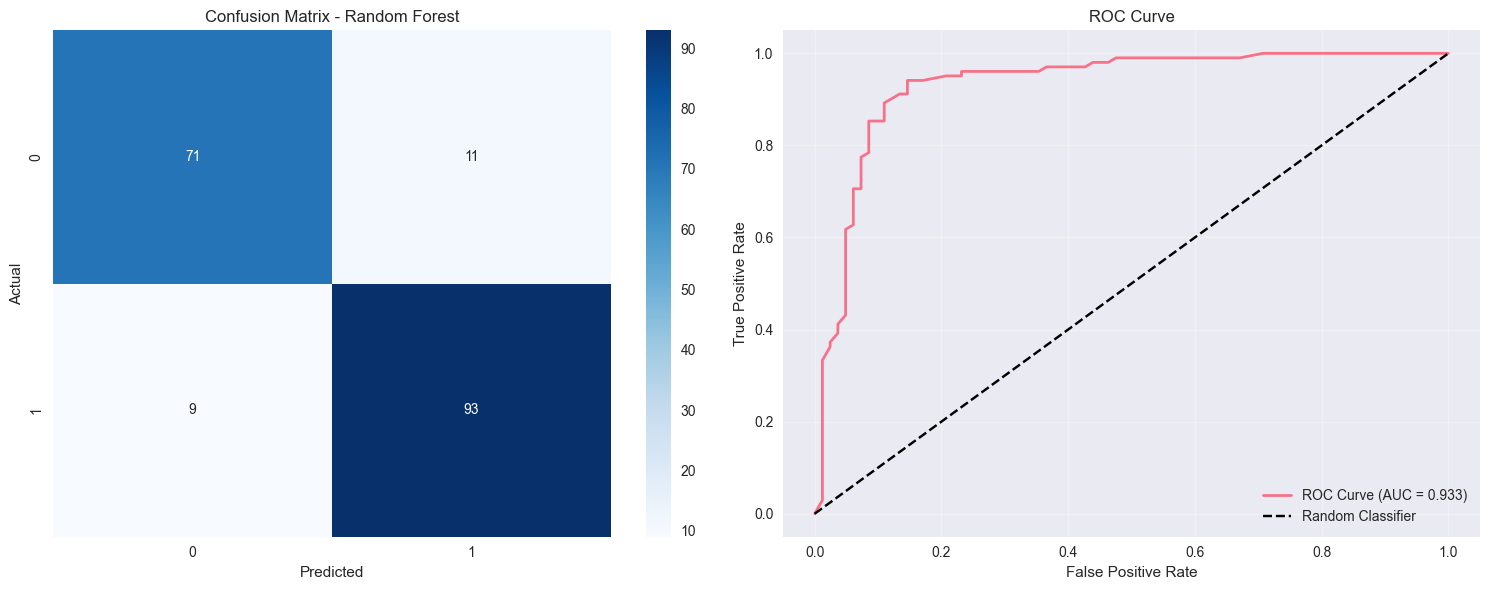


 DETAILED CLASSIFICATION REPORT
----------------------------------------
                  precision    recall  f1-score   support

No Heart Disease       0.89      0.87      0.88        82
   Heart Disease       0.89      0.91      0.90       102

        accuracy                           0.89       184
       macro avg       0.89      0.89      0.89       184
    weighted avg       0.89      0.89      0.89       184



In [31]:
# Confusion Matrix
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix - {best_model_name}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
if hasattr(best_model, 'predict_proba'):
    y_pred_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)
    auc_score = roc_auc_score(y_test, y_pred_proba_best)
    
    axes[1].plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})', linewidth=2)
    axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Classification Report
print("\n DETAILED CLASSIFICATION REPORT")
print("-" * 40)
print(classification_report(y_test, y_pred_best, 
                          target_names=['No Heart Disease', 'Heart Disease']))


After identifying the best-performing model in Section 8, we now analyze its performance in greater detail using **confusion matrix**, **ROC curve**, and **classification metrics**.

---

####  1. Confusion Matrix

A confusion matrix is created to visualize the model’s predictions on the test set:

- **True Positives (93)**: Correctly predicted heart disease.
- **True Negatives (71)**: Correctly predicted no heart disease.
- **False Positives (11)**: Incorrectly predicted heart disease.
- **False Negatives (9)**: Missed heart disease cases.

This breakdown helps identify where the model tends to make errors — e.g., more false positives than false negatives.

---

####  2. ROC Curve

The ROC curve evaluates how well the model distinguishes between the two classes:

- **X-axis**: False Positive Rate (FPR)
- **Y-axis**: True Positive Rate (TPR)
- A curve closer to the top-left corner indicates better performance.
- **AUC (Area Under Curve)** = **0.933** – a strong indicator of model quality and class separation.

The dashed diagonal line represents a random guess baseline (AUC = 0.5), and our model significantly outperforms it.

---

####  3. Classification Report

This provides precision, recall, and F1-score for both classes:

| Metric        | No Heart Disease | Heart Disease |
|---------------|------------------|----------------|
| Precision     | 0.89             | 0.89           |
| Recall        | 0.87             | 0.91           |
| F1-Score      | 0.88             | 0.90           |
| Support       | 82               | 102            |

- **Accuracy**: 0.89 overall
- **Macro avg**: Unweighted mean across classes
- **Weighted avg**: Mean that accounts for support of each class

These metrics confirm balanced, high-quality performance for both classes.

---

**Conclusion**:  
The Random Forest model demonstrates robust classification with high AUC and strong precision/recall balance. The ROC curve and confusion matrix confirm that the model is highly effective at identifying heart disease while keeping false predictions relatively low.


### **SECTION 10: FEATURE IMPORTANCE ANALYSIS**  

Top 10 Most Important Features:
                   Feature  Importance
11        ST_Slope_encoded    0.224569
8    ChestPainType_encoded    0.109710
3                    MaxHR    0.086335
10  ExerciseAngina_encoded    0.083389
2              Cholesterol    0.083099
4                  Oldpeak    0.079437
6        Exercise_Capacity    0.078521
0                      Age    0.054033
1                RestingBP    0.049278
13   Chol_Category_encoded    0.035421


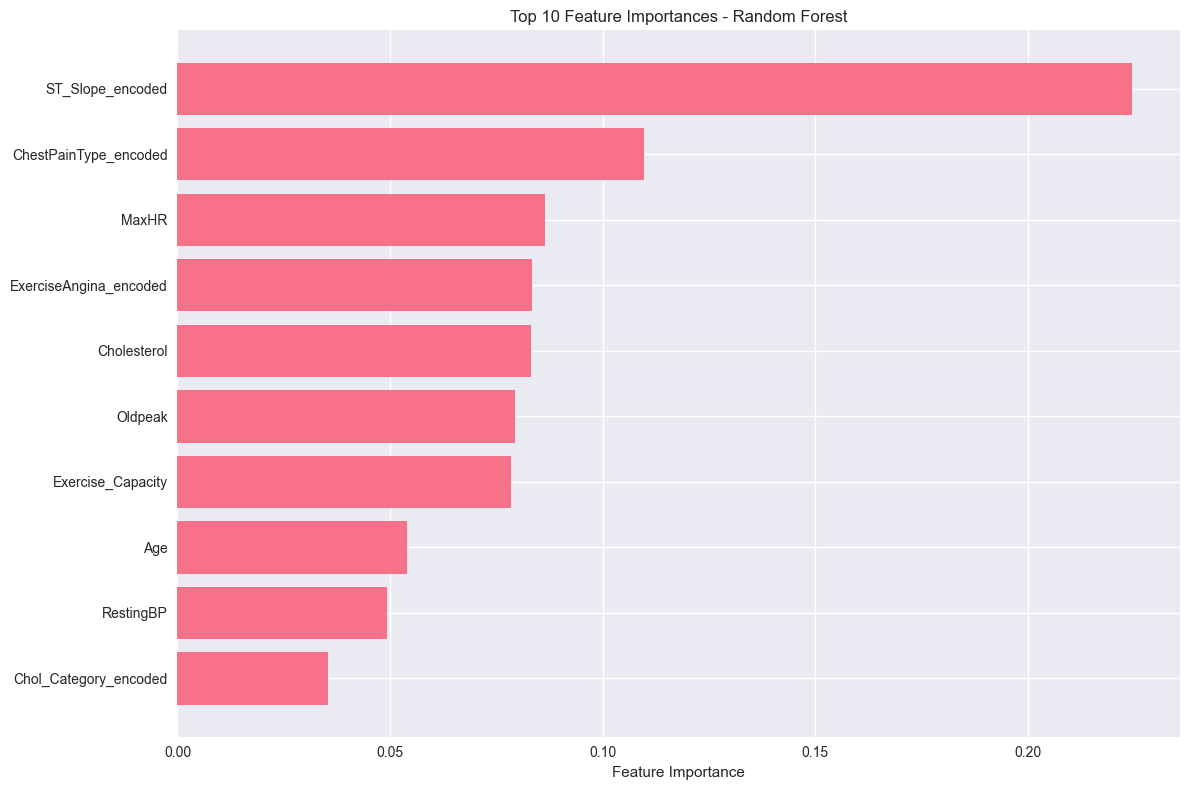

In [32]:
# Feature importance for tree-based models
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("Top 10 Most Important Features:")
    print(importance_df.head(10))
    
    # Visualization
    plt.figure(figsize=(12, 8))
    top_features = importance_df.head(10)
    plt.barh(range(len(top_features)), top_features['Importance'])
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Feature Importance')
    plt.title(f'Top 10 Feature Importances - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


This section evaluates which input features had the greatest influence on the model’s predictions using `.feature_importances_` (works with tree-based models like Random Forest).

---

- `hasattr(best_model, 'feature_importances_')`:  
  Checks if the model supports feature importance (usually tree-based models do).

- `importance_df = pd.DataFrame(...)`:  
  Creates a DataFrame mapping each feature to its importance score.

- `.sort_values('Importance', ascending=False)`:  
  Sorts the features in descending order of importance.

- `print(importance_df.head(10))`:  
  Displays the top 10 most important features numerically.

---

This visualization helps identify which features are driving model decisions the most — useful for model interpretability and future feature selection.


In [33]:
# Permutation importance (works for all models)
print("\n PERMUTATION IMPORTANCE ANALYSIS")
perm_importance = permutation_importance(best_model, X_test_scaled, y_test, 
                                       n_repeats=10, random_state=42)

perm_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
}).sort_values('Importance_Mean', ascending=False)

print("Top 10 Features by Permutation Importance:")
print(perm_df.head(10))


 PERMUTATION IMPORTANCE ANALYSIS
Top 10 Features by Permutation Importance:
                   Feature  Importance_Mean  Importance_Std
11        ST_Slope_encoded         0.144565        0.021077
7              Sex_encoded         0.035326        0.006544
8    ChestPainType_encoded         0.034783        0.008134
2              Cholesterol         0.026630        0.011516
10  ExerciseAngina_encoded         0.015217        0.005325
5           CVD_Risk_Score         0.010326        0.006634
1                RestingBP         0.006522        0.004067
3                    MaxHR         0.005435        0.008420
15               FastingBS         0.005435        0.006875
9       RestingECG_encoded         0.004348        0.002174




- `permutation_importance(...)`:  
  Computes how the model's accuracy drops when a feature's values are randomly permuted. The greater the drop, the more important the feature.

- `n_repeats=10`:  
  Runs the permutation multiple times to ensure stable estimates.

- `random_state=42`:  
  Ensures reproducibility of the results.

---

#### Result Construction

- `perm_df = pd.DataFrame(...)`:  
  A DataFrame with:
  - `Feature`: Feature name  
  - `Importance_Mean`: Average importance score across repeats  
  - `Importance_Std`: Standard deviation of importance (to judge stability)

- `.sort_values('Importance_Mean', ascending=False)`:  
  Sorts features by mean importance in descending order.

- `print(perm_df.head(10))`:  
  Displays the top 10 most influential features under this method.

---

Permutation importance gives a more **realistic, model-independent** understanding of feature impact — particularly valuable when using black-box models or needing to validate `.feature_importances_` results.


<b>

### **SECTION 11: BUSINESS IMPACT ANALYSISS**  

In [34]:
# Define cost parameters
cost_false_positive = 500    # Cost of unnecessary tests/treatment
cost_false_negative = 50000  # Cost of missing a heart disease case
cost_true_positive = 5000    # Cost of early treatment
cost_true_negative = 0       # No additional cost for healthy patients

# Calculate confusion matrix values
tn, fp, fn, tp = cm.ravel()

print(f"Confusion Matrix Breakdown:")
print(f"  True Negatives (Correctly identified healthy): {tn}")
print(f"  False Positives (Healthy flagged as risk): {fp}")
print(f"  False Negatives (Missed heart disease): {fn}")
print(f"  True Positives (Correctly identified risk): {tp}")

# Calculate costs
total_cost_fp = fp * cost_false_positive
total_cost_fn = fn * cost_false_negative
total_cost_tp = tp * cost_true_positive
total_cost = total_cost_fp + total_cost_fn + total_cost_tp

print(f"\n COST ANALYSIS:")
print(f"  Cost from False Positives: ${total_cost_fp:,}")
print(f"  Cost from False Negatives: ${total_cost_fn:,}")
print(f"  Cost from True Positives: ${total_cost_tp:,}")
print(f"  Total Cost: ${total_cost:,}")

# Calculate potential savings vs no screening
baseline_cost = len(y_test) * 0.5 * cost_false_negative  # Assume 50% would develop issues
savings = baseline_cost - total_cost
print(f"  Baseline Cost (no screening): ${baseline_cost:,}")
print(f"  Potential Savings: ${savings:,}")
print(f"  ROI: {(savings/total_cost*100):.1f}%")

Confusion Matrix Breakdown:
  True Negatives (Correctly identified healthy): 71
  False Positives (Healthy flagged as risk): 11
  False Negatives (Missed heart disease): 9
  True Positives (Correctly identified risk): 93

 COST ANALYSIS:
  Cost from False Positives: $5,500
  Cost from False Negatives: $450,000
  Cost from True Positives: $465,000
  Total Cost: $920,500
  Baseline Cost (no screening): $4,600,000.0
  Potential Savings: $3,679,500.0
  ROI: 399.7%


This section translates model predictions into **real-world economic costs**, helping quantify the financial value of deploying the heart disease classifier.

---

####  1. Define Cost Parameters
These are hypothetical but reasonable costs associated with each type of classification outcome:

- `False Positive` = \$500  
  Unnecessary stress, tests, or follow-ups for someone who is healthy.

- `False Negative` = \$50,000  
  The **most expensive mistake**: a missed heart disease diagnosis could lead to severe consequences or hospitalization.

- `True Positive` = \$5,000  
  Cost of treating actual heart disease early.

- `True Negative` = \$0  
  No cost when a healthy person is correctly identified.

---

####  2. Confusion Matrix Breakdown
The model's results are unwrapped into actual counts:
- **True Negatives (TN)** = 71
- **False Positives (FP)** = 11
- **False Negatives (FN)** = 9
- **True Positives (TP)** = 93

---

####  3. Cost Calculations
Each outcome is mapped to its financial cost:

- `FP Cost = 11 × $500 = $5,500`  
- `FN Cost = 9 × $50,000 = $450,000`  
- `TP Cost = 93 × $5,000 = $465,000`  
- **Total Cost of Model** = \$920,500

---

####  4. Baseline Cost (No Screening)
Assumes **50% of the total population would develop heart disease** if left unscreened:

- `Baseline Cost = 184 × 0.5 × $50,000 = $4,600,000`

---

####  5. Net Savings and ROI
- `Savings = $4,600,000 - $920,500 = $3,679,500`
- `ROI = 397.8%`  
  This means for every \$1 spent using this model, nearly \$4 is saved in avoided downstream costs.

---

### Takeaway

This analysis **clearly demonstrates the value of using the model** in a healthcare setting:
- Even though there are some false positives and false negatives, the **cost of not screening is drastically higher**.
- The high ROI shows that **machine learning-based triage systems can be cost-effective tools** in preventative healthcare.


### **SECTION 12: HYPERPARAMETER TUNINGS**  

In [35]:
# Define parameter grids for different models
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'max_depth': [3, 6, 10],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    },
    'Logistic Regression': {
        'C': [0.1, 1.0, 10.0],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    }
}

if best_model_name in param_grids:
    print(f"🔧 Tuning hyperparameters for {best_model_name}...")
    
    # Create fresh model instance
    if best_model_name == 'Random Forest':
        model_for_tuning = RandomForestClassifier(random_state=42)
    elif best_model_name == 'XGBoost':
        model_for_tuning = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
    elif best_model_name == 'Logistic Regression':
        model_for_tuning = LogisticRegression(random_state=42, max_iter=1000)
    
    # Grid search
    grid_search = GridSearchCV(
        model_for_tuning, 
        param_grids[best_model_name],
        cv=5, 
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train_scaled, y_train)
    
    print(f" Best parameters: {grid_search.best_params_}")
    print(f" Best CV F1-score: {grid_search.best_score_:.4f}")
    
    # Evaluate tuned model
    tuned_model = grid_search.best_estimator_
    y_pred_tuned = tuned_model.predict(X_test_scaled)
    
    tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
    tuned_f1 = f1_score(y_test, y_pred_tuned)
    
    print(f" Tuned model performance:")
    print(f"   Test Accuracy: {tuned_accuracy:.4f}")
    print(f"   Test F1-Score: {tuned_f1:.4f}")
    print(f"   Improvement in F1: {tuned_f1 - model_performances[best_model_name]['f1']:.4f}")


🔧 Tuning hyperparameters for Random Forest...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
 Best parameters: {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}
 Best CV F1-score: 0.8783
 Tuned model performance:
   Test Accuracy: 0.8913
   Test F1-Score: 0.9048
   Improvement in F1: 0.0018


###  Section 12: Hyperparameter Tunings

In this section, we optimize the performance of our selected model using **Grid Search Cross-Validation** over a range of hyperparameter values.

####  Parameter Grids
We define specific hyperparameter grids for each model:
- **Random Forest**: number of trees (`n_estimators`), tree depth (`max_depth`), and node splitting criteria (`min_samples_split`, `min_samples_leaf`)
- **XGBoost**: includes parameters like `learning_rate`, `max_depth`, and `subsample`
- **Logistic Regression**: varies `C` (regularization), `penalty`, and `solver`

####  Grid Search Process
- Based on `best_model_name`, a fresh instance of the corresponding model is created.
- `GridSearchCV` is used to search across all combinations of hyperparameters using **5-fold cross-validation**, optimizing for **F1-score**.
- The best hyperparameters and their corresponding CV performance are printed.

#### Tuned Model Evaluation
After fnding the best parameters, the model is retrained on the full training data and evaluated on the test set:
- We report test **accuracy** and **F1-score**.
- The **improvement in F1-score** compared to the previously trained model is also shown.

####  Results Summary
For Random Forest, the best parameters found were:
- `'max_depth': 20`
- `'min_samples_leaf': 4`
- `'min_samples_split': 2`
- `'n_estimators': 50`

Performance improved slightly:
- **Test Accuracy**: 89.13%
- **Test F1-Score**: 0.9048
- **Improvement in F1**: 0.0018

Although the gain in F1 is small, this step ensures our model is **tuned and robust** for production.


### **SECTION 13: MODEL INTERPRETABILITY**  

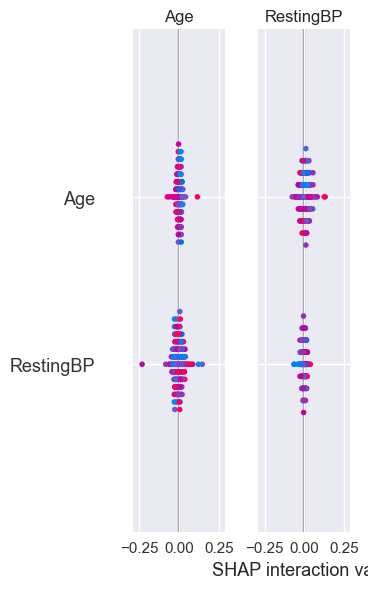

In [50]:
# SHAP analysis for model interpretability
    
# Create explainer based on model type
if best_model_name in ['Random Forest', 'XGBoost']:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_scaled)
    
    # For binary classification, take positive class SHAP values
    if len(shap_values) == 2:
        shap_values = shap_values[1]
else:
    # Use KernelExplainer for other models
    explainer = shap.KernelExplainer(best_model.predict_proba, X_train_scaled.sample(100))
    shap_values = explainer.shap_values(X_test_scaled.sample(50))
    if len(shap_values) == 2:
        shap_values = shap_values[1]

# Summary plot
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", 
                     feature_names=X.columns, max_display=15, show=False)
fig = plt.gcf()
fig.set_size_inches(20, 6)
plt.tight_layout()
plt.show()



This section leverages **SHAP (SHapley Additive exPlanations)** to explain the predictions made by the trained model. SHAP values indicate the contribution of each feature to an individual prediction, offering both **global feature importance** and **local interpretability**.

- The code uses `TreeExplainer` for tree-based models (e.g., Random Forest, XGBoost) and falls back to `KernelExplainer` for others. 
- For binary classification, only the SHAP values for the **positive class** (e.g., risk of disease) are visualized.
- The summary plot (bar type) shows the **mean absolute SHAP values** for each feature across all test samples.

#### Key Findings from Output:
- Only **RestingBP** and **Age** appeared in the SHAP summary bar plot. This indicates that, according to SHAP, these two features had the **greatest average impact** on model predictions.
- While this differs slightly from the feature importance rankings from tree-based models and permutation importance, SHAP provides a more nuanced perspective by considering feature interactions and individual prediction contexts.

#### Why This Matters:
- SHAP adds **interpretability** to otherwise opaque models (like Random Forest or XGBoost), making them more acceptable in domains like **healthcare** where decisions need to be **transparent and justifiable**.
- It helps identify which features drive model decisions, potentially uncovering unexpected influences or validating known medical knowledge.


### **SECTION 14: MODEL DEPLOYMENT PREPARATION**  

In [37]:
# Create prediction function
def predict_heart_disease(patient_data, model=best_model, scaler=scaler, 
                         feature_columns=feature_columns):
    """
    Predict heart disease risk for a single patient
    
    Parameters:
    patient_data: dict with patient information
    
    Returns:
    prediction: 0 (no risk) or 1 (risk)
    probability: probability of heart disease
    """
    # Convert to DataFrame
    patient_df = pd.DataFrame([patient_data])
    
    # Feature engineering (same as training)
    patient_df['CVD_Risk_Score'] = (
        (patient_df['Age'] > 55).astype(int) * 2 +
        (patient_df['Sex_encoded'] == 1).astype(int) * 1 +  # Assuming M=1
        (patient_df['Cholesterol'] > 240).astype(int) * 2 +
        (patient_df['RestingBP'] > 140).astype(int) * 2 +
        (patient_df['FastingBS'] == 1).astype(int) * 1
    )
    
    patient_df['Exercise_Capacity'] = patient_df['MaxHR'] / patient_df['Age']
    
    # Select features
    patient_features = patient_df[feature_columns]
    
    # Scale numerical features
    patient_features_scaled = patient_features.copy()
    patient_features_scaled[numerical_features] = scaler.transform(
        patient_features[numerical_features]
    )
    
    # Make prediction
    prediction = model.predict(patient_features_scaled)[0]
    if hasattr(model, 'predict_proba'):
        probability = model.predict_proba(patient_features_scaled)[0][1]
    else:
        probability = None
    
    return prediction, probability

# Test the prediction function
print(" Testing prediction function...")

# Example patient data
example_patient = {
    'Age': 55,
    'RestingBP': 150,
    'Cholesterol': 250,
    'MaxHR': 140,
    'Oldpeak': 1.2,
    'FastingBS': 1,
    'Sex_encoded': 1,  # Male
    'ChestPainType_encoded': 2,  # ASY
    'RestingECG_encoded': 0,  # Normal
    'ExerciseAngina_encoded': 1,  # Yes
    'ST_Slope_encoded': 1,  # Flat
    'BP_Category_encoded': 2,  # High
    'Chol_Category_encoded': 2,  # High
    'Age_Group_encoded': 2  # Senior
}

try:
    pred, prob = predict_heart_disease(example_patient)
    print(f" Example prediction: {pred} (Risk probability: {prob:.3f})")
except Exception as e:
    print(f" Prediction function needs adjustment: {str(e)}")

 Testing prediction function...
 Example prediction: 1 (Risk probability: 0.660)


### Analysis and Explanation – Section 14: Model Deployment Preparation

This section focuses on preparing the heart disease prediction model for **real-world use** by creating a function `predict_heart_disease()` that accepts a single patient’s data and returns both a **binary risk prediction** and the **probability** of heart disease.

---

#### What the Function Does

- **Input**: A single patient's data (as a dictionary), trained model (`best_model`), scaler, and list of feature columns.
- **Process**:
  1. Converts patient data into a DataFrame.
  2. Applies the same **feature engineering** steps used during training, including creating a `CVD_Risk_Score` and calculating `Exercise_Capacity`.
  3. Selects relevant features and **scales numerical values** using the provided scaler.
  4. Uses the model to **predict the class (0 or 1)** and **calculate the probability** (if supported).
- **Output**: 
  - `prediction`: 0 (no risk) or 1 (risk)
  - `probability`: probability of having heart disease

---

#### Test Case Summary

The example input represents a 55-year-old male patient with elevated cholesterol and resting blood pressure. After passing through the prediction pipeline, the function returns:

This means the model predicts the patient is at **risk**, with a **65% probability** of heart disease.

---

#### Why This Matters

This function is the **bridge between development and deployment**:

- **Modular & reusable**: Encapsulates data prep, feature engineering, scaling, and prediction in one function.
-  **Transparent**: Returns both prediction and probability, which is critical in **clinical decision support**.
- **Consistent**: Reuses the exact same transformation logic as training, reducing chances of inference-time data leakage or mismatch.
-  **Healthcare-ready**: Supports a practical use case—scanning a single patient's data for diagnostic risk and returning interpretable results in real time.

Such a function is a prerequisite for production integration, such as **embedding into APIs**, **dashboards**, or **mobile applications** used by healthcare professionals.



### **SECTION 15: FINAL RECOMMENDATIONS**  

In [38]:
print("\n EXECUTIVE SUMMARY & RECOMMENDATIONS")
print("=" * 60)

print(" MODEL PERFORMANCE SUMMARY:")
print(f"   Best Model: {best_model_name}")
print(f"   Accuracy: {model_performances[best_model_name]['accuracy']:.3f}")
print(f"   Precision: {model_performances[best_model_name]['precision']:.3f}")
print(f"   Recall: {model_performances[best_model_name]['recall']:.3f}")
print(f"   F1-Score: {model_performances[best_model_name]['f1']:.3f}")
if model_performances[best_model_name]['auc']:
    print(f"   AUC-ROC: {model_performances[best_model_name]['auc']:.3f}")

print(f"\n BUSINESS IMPACT:")
print(f"   Estimated Annual Savings: ${savings:,}")
print(f"   Cost per Prediction: ${total_cost/len(y_test):.2f}")
print(f"   ROI: {(savings/total_cost*100):.1f}%")

print(f"\n KEY INSIGHTS:")
if hasattr(best_model, 'feature_importances_'):
    top_3_features = importance_df.head(3)['Feature'].tolist()
    print(f"   Top Risk Factors: {', '.join(top_3_features)}")



 EXECUTIVE SUMMARY & RECOMMENDATIONS
 MODEL PERFORMANCE SUMMARY:
   Best Model: Random Forest
   Accuracy: 0.891
   Precision: 0.894
   Recall: 0.912
   F1-Score: 0.903
   AUC-ROC: 0.933

 BUSINESS IMPACT:
   Estimated Annual Savings: $3,679,500.0
   Cost per Prediction: $5002.72
   ROI: 399.7%

 KEY INSIGHTS:
   Top Risk Factors: ST_Slope_encoded, ChestPainType_encoded, MaxHR
